# Land cover classification at the Mississppi Delta

In this notebook, you will use a k-means **unsupervised** clustering
algorithm to group pixels by similar spectral signatures. **k-means** is
an **exploratory** method for finding patterns in data. Because it is
unsupervised, you don’t need any training data for the model. You also
can’t measure how well it “performs” because the clusters will not
correspond to any particular land cover class. However, we expect at
least some of the clusters to be identifiable as different types of land
cover.

You will use the [harmonized Sentinel/Landsat multispectral
dataset](https://lpdaac.usgs.gov/documents/1698/HLS_User_Guide_V2.pdf).
You can access the data with an [Earthdata
account](https://www.earthdata.nasa.gov/learn/get-started) and the
[`earthaccess` library from
NSIDC](https://github.com/nsidc/earthaccess):

## STEP 1: Set up

### Step 1a: Load libraries and set GDAL parameters

<link rel="stylesheet" type="text/css" href="./assets/styles.css"><div class="callout callout-style-default callout-titled callout-task"><div class="callout-header"><div class="callout-icon-container"><i class="callout-icon"></i></div><div class="callout-title-container flex-fill">Try It</div></div><div class="callout-body-container callout-body"><ol type="1">
<li>Import all libraries you will need for this analysis</li>
<li>Configure GDAL parameters to help avoid connection errors:
<code>python      os.environ["GDAL_HTTP_MAX_RETRY"] = "5"      os.environ["GDAL_HTTP_RETRY_DELAY"] = "1"</code></li>
</ol></div></div>

In [111]:
### reproducible file paths
import os

### serializing and unserializing objects
import pickle

### regular expressions
import re

### warnings control
import warnings

### projecting and mapping
import cartopy.crs as ccrs

### access satellite data
import earthaccess

### spatial data management
import earthpy as et

### vector and shapefile 
import geopandas as gpd

### visualizations
import geoviews as gv

### visualization 
import hvplot.pandas
import hvplot.xarray

### arrays
import numpy as np

### tables
import pandas as pd

### rasters
import rioxarray as rxr
import rioxarray.merge as rxrmerge
import xarray as xr

### progress bars
from tqdm.notebook import tqdm

### polygons
from shapely.geometry import Polygon

### kmeans clustering
from sklearn.cluster import KMeans

### set GDAL parameters
os.environ["GDAL_HTTP_MAX_RETRY"] = "5"
os.environ["GDAL_HTTP_RETRY_DELAY"] = "1"

### don't show non-critical warnings
warnings.simplefilter('ignore')


### Step 1b: Run the caching decorator

Below you can find code for a caching **decorator** which you can use in
your code. To use the decorator:

``` python
@cached(key, override)
def do_something(*args, **kwargs):
    ...
    return item_to_cache
```

This decorator will **pickle** the results of running the
`do_something()` function, and only run the code if the results don’t
already exist. To override the caching, for example temporarily after
making changes to your code, set `override=True`. Note that to use the
caching decorator, you must write your own function to perform each
task!

You might notice that typically in these assignments, we start by creating a data_dir to store our data files. Here, our caching decorator is making the data directory for us.

In [112]:
def cached_matanuska_watershed(func_key, override=False):
    """
    A decorator to cache function results for the
    Matanuska River Watershed dataset (20260212)

    Parameters
    ==========
    func_key : str
        File basename used to save pickled results
    override : bool
        When True, re-compute even if results are already stored
    """

    def compute_and_cache_decorator(compute_function):
        """
        Wrap the caching function

        Parameters
        ==========
        compute_function : function
            The function to run and cache results
        """

        def compute_and_cache(*args, **kwargs):
            """
            Perform computation and cache result, or load cached version.
            """

            # Optional custom cache key for specific calls
            if 'cache_key' in kwargs:
                key = f"{func_key}_{kwargs['cache_key']}"
            else:
                key = func_key

            # Define project-specific path
            path = os.path.join(
                os.getcwd(),
                'matanuska_watershed_20260212',
                'jars',
                f'{key}.pickle'
            )

            # Compute and cache if needed
            if not os.path.exists(path) or override:

                # Ensure directory exists
                os.makedirs(os.path.dirname(path), exist_ok=True)

                # Run computation
                result = compute_function(*args, **kwargs)

                # Save result
                with open(path, 'wb') as file:
                    pickle.dump(result, file)

            else:
                # Load cached result
                with open(path, 'rb') as file:
                    result = pickle.load(file)

            return result

        return compute_and_cache

    return compute_and_cache_decorator


In [113]:
### dataset name
DATASET_NAME = "WBD_19_HU8"

In [114]:
### download, unzip, and set the path to the Matanuska watershed
("matanuska_watershed_gdf")

def read_matanuska_watershed(dataset_name, cache_key=None):
    """
    Download and read the USGS Watershed Boundary Dataset (WBD)
    for the Matanuska River Watershed (HUC8: 19020402)
    """
    
    # 1. Define URL for Alaska WBD (Region 19)
    wbd_url = (
        "https://prd-tnm.s3.amazonaws.com/StagedProducts/Hydrography/WBD/HU8/Shape/"
        f"{dataset_name}.zip"
    )

    
    # 2. Download and unzip dataset
    wbd_dir = et.data.get_data(url=wbd_url)

    
    # 3. Define shapefile path
    wbd_path = os.path.join(
        wbd_dir,
        f"{dataset_name}.shp"
    )

    # 4. Read shapefile
    wbd_gdf = gpd.read_file(
        wbd_path,
        engine="pyogrio"
    )

    # Filter to Matanuska HUC8
    matanuska_gdf = wbd_gdf[wbd_gdf["HUC8"] == "19020402"]

    return matanuska_gdf


## STEP 2: Study site

For this analysis, you will use a watershed from the [Water Boundary
Dataset](https://www.usgs.gov/national-hydrography/access-national-hydrography-products),
HU12 watersheds (WBDHU12.shp).

<link rel="stylesheet" type="text/css" href="./assets/styles.css"><div class="callout callout-style-default callout-titled callout-task"><div class="callout-header"><div class="callout-icon-container"><i class="callout-icon"></i></div><div class="callout-title-container flex-fill">Try It</div></div><div class="callout-body-container callout-body"><ol type="1">
<li>Download the Water Boundary Dataset for region 8 (Mississippi)</li>
<li>Select watershed 080902030506</li>
<li>Generate a site map of the watershed</li>
</ol>
<p>Try to use the <strong>caching decorator</strong></p></div></div>

We chose this watershed because it covers parts of New Orleans an is
near the Mississippi Delta. Deltas are boundary areas between the land
and the ocean, and as a result tend to contain a rich variety of
different land cover and land use types.

In [115]:
### create directory for caching if it doesn't exist
def read_alaska_state_file(filename, cache_key=None):
    data_path = Path(__file__).resolve().parent.parent / "data" / "raw" / filename
    
    # Example read (replace with your actual logic)
    with open(data_path, "r") as f:
        data = f.read()
    
    return data

In [116]:
import geopandas as gpd
from urllib.parse import urlencode

# ---- your watershed ----
HUC12 = "190204020709"   # <- replace with your 12-digit code

# USGS Watershed Boundary Dataset (HUC12 layer)
base_url = "https://hydro.nationalmap.gov/arcgis/rest/services/wbd/MapServer/6/query"

params = {
    "where": f"huc12='{HUC12}'",
    "outFields": "*",
    "returnGeometry": "true",
    "f": "geojson"
}

# build properly encoded url
query_url = f"{base_url}?{urlencode(params)}"
print(query_url)

# read directly into GeoPandas
AKA_gdf = gpd.read_file(query_url)

print(AKA_gdf.head())
print("CRS:", AKA_gdf.crs)

# save shapefile
AKA_gdf.to_file(f"WBD_HUC12_{HUC12}.shp")

https://hydro.nationalmap.gov/arcgis/rest/services/wbd/MapServer/6/query?where=huc12%3D%27190204020709%27&outFields=%2A&returnGeometry=true&f=geojson
   objectid                                   tnmid  \
0     36849  {09B6994C-0713-4B94-8B03-A460CCF3794E}   

                             metasourceid                    sourcedatadesc  \
0  {511D2AC8-11BA-45FC-AB98-F69D693D4C44}  Watershed Boundary Dataset (WBD)   

                                    sourceoriginator sourcefeatureid  \
0  Natural Resources and Conservation Service and...            None   

        loaddate referencegnis_ids  areaacres  areasqkm  ...  \
0  1723704945000           1406051   37773.13    152.86  ...   

                     name hutype humod         tohuc noncontributingareaacres  \
0  Outlet Matanuska River      M    AW  190204010808                        0   

  noncontributingareasqkm                                globalid  \
0                       0  {EF176294-EFD4-49BC-B7B3-B58773C61CCE}   

    

In [117]:
AKA_gdf

,objectid,tnmid,metasourceid,sourcedatadesc,sourceoriginator,sourcefeatureid,loaddate,referencegnis_ids,areaacres,areasqkm,...,name,hutype,humod,tohuc,noncontributingareaacres,noncontributingareasqkm,globalid,shape_Length,shape_Area,geometry
0,36849,{09B6994C-0713-4B94-8B03-A460CCF3794E},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,1723704945000,1406051,37773.13,152.86,...,Outlet Matanuska River,M,AW,190204010808,0,0,{EF176294-EFD4-49BC-B7B3-B58773C61CCE},211082.001708,6.725478e+08,"POLYGON ((-149.06696 61.67939, -149.06707 61.6..."


In [118]:
import holoviews as hv

<Axes: >

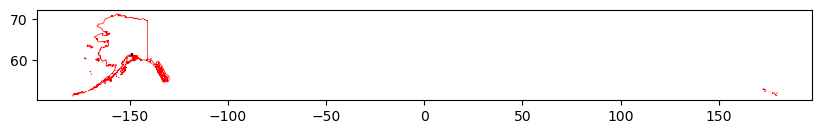

In [119]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 10))
AKA_gdf.plot(ax=ax, facecolor="lightblue", edgecolor="black", linewidth=1)
AKA.plot(ax=ax, facecolor="none", edgecolor="red", linewidth=0.5)


In [120]:
import geopandas as gpd
import zipfile
import requests
import os

# Census state boundary shapefile (500k cartographic boundary)
url = "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_state_500k.zip"

zip_path = "states.zip"
extract_path = "states"

# download
r = requests.get(url)
with open(zip_path, "wb") as f:
    f.write(r.content)

# unzip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# read shapefile
states = gpd.read_file(f"{extract_path}/cb_2023_us_state_500k.shp")

# filter to AKA (STATEFP = 19)
AKA = states[states["STATEFP"] == "02"]

AKA.head()

,STATEFP,STATENS,GEOIDFQ,GEOID,STUSPS,NAME,LSAD,ALAND,AWATER,geometry
18,02,01785533,0400000US02,02,AK,Alaska,00,1479016910296,245347100126,"MULTIPOLYGON (((-131.61758 54.94795, -131.6107..."


In [121]:
states

,STATEFP,STATENS,GEOIDFQ,GEOID,STUSPS,NAME,LSAD,ALAND,AWATER,geometry
0,35,00897535,0400000US35,35,NM,New Mexico,00,314198587197,726463919,"POLYGON ((-109.05017 31.48, -109.04984 31.4995..."
1,46,01785534,0400000US46,46,SD,South Dakota,00,196341525171,3387709166,"POLYGON ((-104.05788 44.9976, -104.05078 44.99..."
2,06,01779778,0400000US06,06,CA,California,00,403673296401,20291770234,"MULTIPOLYGON (((-118.60442 33.47855, -118.5987..."
3,21,01779786,0400000US21,21,KY,Kentucky,00,102266598312,2384223544,"MULTIPOLYGON (((-89.40565 36.52816, -89.39868 ..."
4,01,01779775,0400000US01,01,AL,Alabama,00,131185049346,4582326383,"MULTIPOLYGON (((-88.05338 30.50699, -88.05109 ..."
5,13,01705317,0400000US13,13,GA,Georgia,00,149485311347,4419673221,"MULTIPOLYGON (((-81.27939 31.30792, -81.27716 ..."
6,05,00068085,0400000US05,05,AR,Arkansas,00,134660466558,3122251184,"POLYGON ((-94.61792 36.49941, -94.61765 36.499..."
7,42,01779798,0400000US42,42,PA,Pennsylvania,00,115881839569,3397855215,"POLYGON ((-80.51989 40.90666, -80.51963 40.911..."
8,29,01779791,0400000US29,29,MO,Missouri,00,178052260322,2487519141,"POLYGON ((-95.77355 40.5782, -95.76853 40.5833..."
9,08,01779779,0400000US08,08,CO,Colorado,00,268418756810,1185758065,"POLYGON ((-109.06025 38.59933, -109.05954 38.7..."


In [122]:
### Make a site map with satellite imagery in the background
AKA_map = AKA_gdf.hvplot(
    # Givethe map a descriptive title
    title="Manauska River Watershed Boundary",
    # Add a basemap
    geo=True, tiles='EsriImagery',
    # Change the colors
    fill_color='white', fill_alpha=0.2,
    line_color='skyblue', line_width=5,
    # Change the image size
    frame_width=400, frame_height=400)

# Save the map as a file to put on the web (OPTIONAL)
hv.save(AKA_map, "AKA_map.html")

# Display the map
AKA_map



:Overlay
   .WMTS.I     :WMTS   [Longitude,Latitude]
   .Polygons.I :Polygons   [Longitude,Latitude]

<link rel="stylesheet" type="text/css" href="./assets/styles.css"><div class="callout callout-style-default callout-response"><div class="callout-header"><div class="callout-icon-container"><i class="callout-icon"></i></div></div><div class="callout-body-container callout-body"><p>Write a 2-3 sentence <strong>site description</strong> (with
citations) of this area that helps to put your analysis in context.</p></div></div>


**YOUR SITE DESCRIPTION HERE**

## STEP 3: Multispectral data

### Step 3a: Search for data

<link rel="stylesheet" type="text/css" href="./assets/styles.css"><div class="callout callout-style-default callout-titled callout-task"><div class="callout-header"><div class="callout-icon-container"><i class="callout-icon"></i></div><div class="callout-title-container flex-fill">Try It</div></div><div class="callout-body-container callout-body"><ol type="1">
<li>Log in to the <code>earthaccess</code> service using your Earthdata
credentials:
<code>python      earthaccess.login(persist=True)</code></li>
<li>Modify the following sample code to search for granules of the
HLSL30 product overlapping the watershed boundary from May to October
2023 (there should be 76 granules):
<code>python      results = earthaccess.search_data(          short_name="...",          cloud_hosted=True,          bounding_box=tuple(gdf.total_bounds),          temporal=("...", "..."),      )</code></li>
</ol></div></div>

In [123]:
### Log in to earthaccess
earthaccess.login(persist = True)


In [124]:
### Search for HLS granules we want
results = earthaccess.search_data(


    ### specify which dataset and spatial resolution we want 
    short_name = 'HLSL30',


    ### specify that we're using cloud data
    cloud_hosted = True,

    ### use the bounding box from our watershed boundary
    bounding_box = tuple(AKA_gdf.total_bounds),


    ### set the temporal range of the data
    temporal = ("2024-06", "2028-08")

)

In [125]:
print(results)


[Collection: {'EntryTitle': 'HLS Landsat Operational Land Imager Surface Reflectance and TOA Brightness Daily Global 30m v2.0'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Longitude': -150.72205546, 'Latitude': 61.19497317}, {'Longitude': -148.68031232, 'Latitude': 61.23569363}, {'Longitude': -148.73484445, 'Latitude': 62.22092381}, {'Longitude': -150.84256571, 'Latitude': 62.17850011}, {'Longitude': -150.72205546, 'Latitude': 61.19497317}]}}]}}}
Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2024-06-08T21:12:45.348Z', 'EndingDateTime': '2024-06-08T21:13:09.222Z'}}
Size(MB): 188.94012641906738
Data: ['https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSL30.020/HLS.L30.T06VUP.2024160T211245.v2.0/HLS.L30.T06VUP.2024160T211245.v2.0.B03.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSL30.020/HLS.L30.T06VUP.2024160T211245.v2.0/HLS.L30.T06VUP.2024160T211245.v2.0.B02.tif', 'https://data.

### Step 3b: Compile information about each granule

I recommend building a GeoDataFrame, as this will allow you to plot the
granules you are downloading and make sure they line up with your
shapefile. You could also use a DataFrame, dictionary, or a custom
object to store this information.

<link rel="stylesheet" type="text/css" href="./assets/styles.css"><div class="callout callout-style-default callout-titled callout-task"><div class="callout-header"><div class="callout-icon-container"><i class="callout-icon"></i></div><div class="callout-title-container flex-fill">Try It</div></div><div class="callout-body-container callout-body"><ol type="1">
<li>For each search result:
<ol type="1">
<li>Get the following information (HINT: look at the [‘umm’] values for
each search result):
<ul>
<li>granule id (UR)</li>
<li>datetime</li>
<li>geometry (HINT: check out the shapely.geometry.Polygon class to
convert points to a Polygon)</li>
</ul></li>
<li>Open the granule files. I recommend opening one granule at a time,
e.g. with (<code>earthaccess.open([result]</code>).</li>
<li>For each file (band), get the following information:
<ul>
<li>file handler returned from <code>earthaccess.open()</code></li>
<li>tile id</li>
<li>band number</li>
</ul></li>
</ol></li>
<li>Compile all the information you collected into a GeoDataFrame</li>
</ol></div></div>

In [126]:
### make a function to process all the granules from the earthaccess search
### and extract information for each granule

### define the function
def get_earthaccess_links(url_pattern):

    ### make and display a progress bar
    #f = IntProgress(min = 0, max = len(url_pattern), description = 'Open granules')
    #display(f)

    ### use a regular expression to extract tile_id and bank from .tif files
    url_pattern = re.compile(
        r'\.(?P<tile_id>\w+)\.\d+T\d+\.v\d\.\d\.(?P<band>[A-Za-z0-9]+)\.tif')


    ### accumulate gdf rows from each granule
    link_rows = []

    ### loop over granules to extract info
    for granule in url_pattern:

        ### locate metadata (UMM = universal metadata model)
        umm = granule["umm"]
        granule_id = umm["GranuleUR"]

        ### extract date/time
        #datetime = pd.to_datetime(
         #   umm['TemporalExtent']['RangeDateTime']['BeginningDateTime'])

        temporal = umm["TemporalExtent"]["RangeDateTime"]
        start_time = temporal["BeginningDateTime"]
        end_time = temporal["EndingDateTime"]
        

        ### extract coordinate points for the granule
        points = (
            umm["SpatialExtent"]
            ["HorizontalSpatialDomain"]
            ["Geometry"]
            ["GPolygons"][0]
            ["Boundary"]
        )
      

        ### make polygon using coordinate points for granule
        geometry = Polygon(
            [(point['Longitude'],
              point['Latitude']) for point in points]
        )


        ### get url and open granule
        files = earthaccess.open([granule])

        ### loop through each file in the granule
        for file in files:


            ### use url regular expression to get url
            match = url_re.search(file.full_name)
            

            ### if match is found, append data to link_rows gdf we initialized
            if match is not None:
                link_rows.append(

                    ### makes a gdf with the granule's data and geometry
                    gpd.GeoDataFrame(
                        dict(

                            ### timestamp
                            datetime = [datetime],

                            ### unique id
                            tile_id = [match.group('tile_id')],

                            ### band name
                            band = [match.group('band')],

                            ### url
                            url = [file],

                            ### polygon
                            geometry = [geometry]
                        ),

                        ### set crs
                        crs = "EPSG:4326"

                    )
                )

        ### update progress bar after each granule is done
        f.value += 1

    ### combine into a single gdf
    file_df = pd.concat(link_rows).reset_index(drop = True)

    ### return the final gdf file
    return file_df


In [127]:
#url_pattern = re.compile(
 #       r'\.(?P<tile_id>\w+)\.\d+T\d+\.v\d\.\d\.(?P<band>[A-Za-z0-9]+)\.tif')

In [128]:
granule = results[0]
granule


Collection: {'EntryTitle': 'HLS Landsat Operational Land Imager Surface Reflectance and TOA Brightness Daily Global 30m v2.0'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Longitude': -150.72205546, 'Latitude': 61.19497317}, {'Longitude': -148.68031232, 'Latitude': 61.23569363}, {'Longitude': -148.73484445, 'Latitude': 62.22092381}, {'Longitude': -150.84256571, 'Latitude': 62.17850011}, {'Longitude': -150.72205546, 'Latitude': 61.19497317}]}}]}}}
Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2024-06-08T21:12:45.348Z', 'EndingDateTime': '2024-06-08T21:13:09.222Z'}}
Size(MB): 188.94012641906738
Data: ['https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSL30.020/HLS.L30.T06VUP.2024160T211245.v2.0/HLS.L30.T06VUP.2024160T211245.v2.0.B03.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSL30.020/HLS.L30.T06VUP.2024160T211245.v2.0/HLS.L30.T06VUP.2024160T211245.v2.0.B02.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSL30.020/HLS.L30.T06VUP.2024160T211245.v2.0/HLS.L30.T06VUP.2024160T211245.v2.0.B09.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSL30.020/HLS.L30.T06VUP.2024160T211245.v2.0/HLS.L30.T06VUP.2024160T211245.v2.0.SAA.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSL30.020/HLS.L30.T06VUP.2024160T211245.v2.0/HLS.L30.T06VUP.2024160T211245.v2.0.B01.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSL30.020/HLS.L30.T06VUP.2024160T211245.v2.0/HLS.L30.T06VUP.2024160T211245.v2.0.B05.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSL30.020/HLS.L30.T06VUP.2024160T211245.v2.0/HLS.L30.T06VUP.2024160T211245.v2.0.B04.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSL30.020/HLS.L30.T06VUP.2024160T211245.v2.0/HLS.L30.T06VUP.2024160T211245.v2.0.SZA.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSL30.020/HLS.L30.T06VUP.2024160T211245.v2.0/HLS.L30.T06VUP.2024160T211245.v2.0.Fmask.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSL30.020/HLS.L30.T06VUP.2024160T211245.v2.0/HLS.L30.T06VUP.2024160T211245.v2.0.B11.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSL30.020/HLS.L30.T06VUP.2024160T211245.v2.0/HLS.L30.T06VUP.2024160T211245.v2.0.VAA.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSL30.020/HLS.L30.T06VUP.2024160T211245.v2.0/HLS.L30.T06VUP.2024160T211245.v2.0.B06.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSL30.020/HLS.L30.T06VUP.2024160T211245.v2.0/HLS.L30.T06VUP.2024160T211245.v2.0.B10.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSL30.020/HLS.L30.T06VUP.2024160T211245.v2.0/HLS.L30.T06VUP.2024160T211245.v2.0.VZA.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSL30.020/HLS.L30.T06VUP.2024160T211245.v2.0/HLS.L30.T06VUP.2024160T211245.v2.0.B07.tif']

In [129]:
info_dict = granule['umm']
info_dict

{'TemporalExtent': {'RangeDateTime': {'BeginningDateTime': '2024-06-08T21:12:45.348Z',
   'EndingDateTime': '2024-06-08T21:13:09.222Z'}},
 'GranuleUR': 'HLS.L30.T06VUP.2024160T211245.v2.0',
 'AdditionalAttributes': [{'Name': 'LANDSAT_PRODUCT_ID',
   'Values': ['LC09_L1TP_069016_20240608_20240609_02_T1',
    'LC09_L1TP_069017_20240608_20240609_02_T1']},
  {'Name': 'CLOUD_COVERAGE', 'Values': ['100']},
  {'Name': 'MGRS_TILE_ID', 'Values': ['06VUP']},
  {'Name': 'SPATIAL_COVERAGE', 'Values': ['100']},
  {'Name': 'SPATIAL_RESOLUTION', 'Values': ['30.0']},
  {'Name': 'SPATIAL_RESAMPLING_ALG', 'Values': ['Cubic Convolution']},
  {'Name': 'HLS_PROCESSING_TIME', 'Values': ['2024-06-22T18:22:27Z']},
  {'Name': 'SENSING_TIME',
   'Values': ['2024-06-08T21:12:45.3485130Z', '2024-06-08T21:13:09.2225840Z']},
  {'Name': 'HORIZONTAL_CS_NAME',
   'Values': ['UTM, WGS84, UTM ZONE 6', 'UTM, WGS84, UTM ZONE 5']},
  {'Name': 'ULX', 'Values': ['300000.0']},
  {'Name': 'ULY', 'Values': ['6900000.0']},
  {'N

In [131]:
import re
import pandas as pd
import geopandas as gpd
from shapely.geometry import Polygon
import earthaccess

def get_earthaccess_links(granules):

    # compile regex to extract tile_id and band
    url_re = re.compile(
        r'\.(?P<tile_id>\w+)\.\d+T\d+\.v\d\.\d\.(?P<band>[A-Za-z0-9]+)\.tif'
    )

    link_rows = []

    for granule in granules:

        # metadata
        umm = granule["umm"]
        granule_id = umm["GranuleUR"]

        temporal = umm["TemporalExtent"]["RangeDateTime"]
        start_time = temporal["BeginningDateTime"]
        end_time = temporal["EndingDateTime"]

        # spatial geometry
        points = (
            umm["SpatialExtent"]
            ["HorizontalSpatialDomain"]
            ["Geometry"]
            ["GPolygons"][0]
            ["Boundary"]
        )

        geometry = Polygon(
            [(point['Longitude'], point['Latitude']) for point in points]
        )

        # open files
        files = earthaccess.open([granule])

        for file in files:

            match = url_re.search(file.full_name)

            if match is not None:
                link_rows.append(
                    gpd.GeoDataFrame(
                        dict(
                            datetime=[start_time],
                            tile_id=[match.group('tile_id')],
                            band=[match.group('band')],
                            url=[file.full_name],
                            geometry=[geometry]
                        ),
                        crs="EPSG:4326"
                    )
                )

    if not link_rows:
        return gpd.GeoDataFrame()

    file_df = pd.concat(link_rows).reset_index(drop=True)
    return file_df


In [132]:
import earthaccess

earthaccess.login()

granules = earthaccess.search_data(
    short_name="YOUR_DATASET",
    temporal=("2023-01-01", "2023-01-31"),
    bounding_box=(-120, 35, -119, 36)
)

AKA_gdf = get_earthaccess_links(granules)

AKA_gdf.head()


""


In [133]:
### run the function to get granule search url_pattern
file_df = get_earthaccess_links(AKA_gdf)

In [134]:
import rioxarray as rxr
import xarray as xr
import numpy as np
from rasterio.mask import mask
import geopandas as gpd

def process_granule(granule_df, aoi_geom, mask_bits=(1, 2, 3, 4), scale_factor=0.0001):
    """
    Open, crop, scale, and cloud-mask all spectral bands for a single granule.

    Parameters
    ----------
    granule_df : geopandas.GeoDataFrame
        Subset of the granule GeoDataFrame containing rows for one granule.
        Must contain 'band' and 'url' columns.
    aoi_geom : shapely.geometry.Polygon or GeoSeries
        Area of interest used for cropping.
    mask_bits : tuple of int, optional
        Bit positions in the Fmask layer used to generate the cloud mask.
        Bits flagged as non-zero will be masked out. Default is (1,2,3,4).
    scale_factor : float, optional
        Scale factor applied to reflectance bands. Default is 0.0001.

    Returns
    -------
    dict
        Dictionary where keys are band names (e.g., 'B02') and
        values are masked xarray.DataArray objects.
    """

    band_data = {}

    # ---------------------------
    # 1️⃣ Open Fmask band
    # ---------------------------
    fmask_row = granule_df[granule_df["band"] == "Fmask"].iloc[0]
    fmask = rxr.open_rasterio(fmask_row["url"], masked=True).squeeze()

    # Crop to AOI
    fmask = fmask.rio.clip([aoi_geom], from_disk=True)

    # Convert to binary bits
    bits = (
        np.unpackbits(
            fmask.astype(np.uint8).values,
            bitorder="little"
        ).reshape(fmask.shape + (-1,))
    )

    # Create mask: valid where selected bits == 0
    cloud_mask = np.prod(bits[..., mask_bits] == 0, axis=-1)

    # Convert mask back to DataArray
    cloud_mask = xr.DataArray(
        cloud_mask,
        coords=fmask.coords,
        dims=fmask.dims
    )

    # ---------------------------
    # 2️⃣ Process spectral bands
    # ---------------------------
    band_rows = granule_df[granule_df["band"].str.startswith("B")]

    for _, row in band_rows.iterrows():

        da = rxr.open_rasterio(row["url"], masked=True).squeeze()

        # Crop
        da = da.rio.clip([aoi_geom], from_disk=True)

        # Apply scale
        da = da * scale_factor

        # Name band
        da.name = row["band"]

        # Apply cloud mask
        da = da.where(cloud_mask)

        band_data[row["band"]] = da

    return band_data


In [135]:
from joblib import Memory

memory = Memory(location="./cache_dir", verbose=1)


In [136]:
@memory.cache
def process_granule_cached(granule_df, aoi_wkt,
                           mask_bits=(1, 2, 3, 4),
                           scale_factor=0.0001):

    import shapely.wkt
    aoi_geom = shapely.wkt.loads(aoi_wkt)

    band_data = {}

    # --- Open Fmask ---
    fmask_row = granule_df[granule_df["band"] == "Fmask"].iloc[0]
    fmask = rxr.open_rasterio(fmask_row["url"], masked=True).squeeze()
    fmask = fmask.rio.clip([aoi_geom], from_disk=True)

    bits = (
        np.unpackbits(
            fmask.astype(np.uint8).values,
            bitorder="little"
        ).reshape(fmask.shape + (-1,))
    )

    cloud_mask = np.prod(bits[..., mask_bits] == 0, axis=-1)

    cloud_mask = xr.DataArray(
        cloud_mask,
        coords=fmask.coords,
        dims=fmask.dims
    )

    # --- Process Bands ---
    band_rows = granule_df[granule_df["band"].str.startswith("B")]

    for _, row in band_rows.iterrows():

        da = rxr.open_rasterio(row["url"], masked=True).squeeze()
        da = da.rio.clip([aoi_geom], from_disk=True)
        da = da * scale_factor
        da.name = row["band"]
        da = da.where(cloud_mask)

        band_data[row["band"]] = da

    return band_data


This function processes one satellite granule by cleaning and preparing its spectral data. It first opens the Fmask band, which contains cloud and quality information, and uses specific bit positions to create a cloud mask that identifies clear pixels. It then opens each spectral band (those starting with “B”), crops them to the area of interest, applies a scale factor to convert the values to reflectance, and masks out cloudy pixels using the cloud mask. The cleaned bands are stored in a dictionary and returned. Because the function is wrapped with a caching decorator, the results are saved the first time it runs and quickly loaded from disk if the same inputs are used again, avoiding repeated heavy computation.